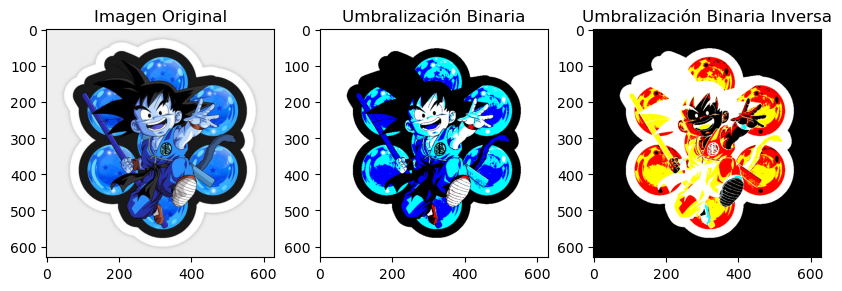

In [4]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('goku.jpg') # lee en escala de grises
#umbralizacion binaria
_, umbral_binario = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY)
# umbralizacion binaria inversa
_,umbral_binario_inv = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')

plt.subplot(1, 3, 2)
plt.title('Umbralización Binaria')
plt.imshow(umbral_binario, cmap='gray')

plt.subplot(1, 3, 3)
plt.title('Umbralización Binaria Inversa')
plt.imshow(umbral_binario_inv, cmap='gray')

plt.show()

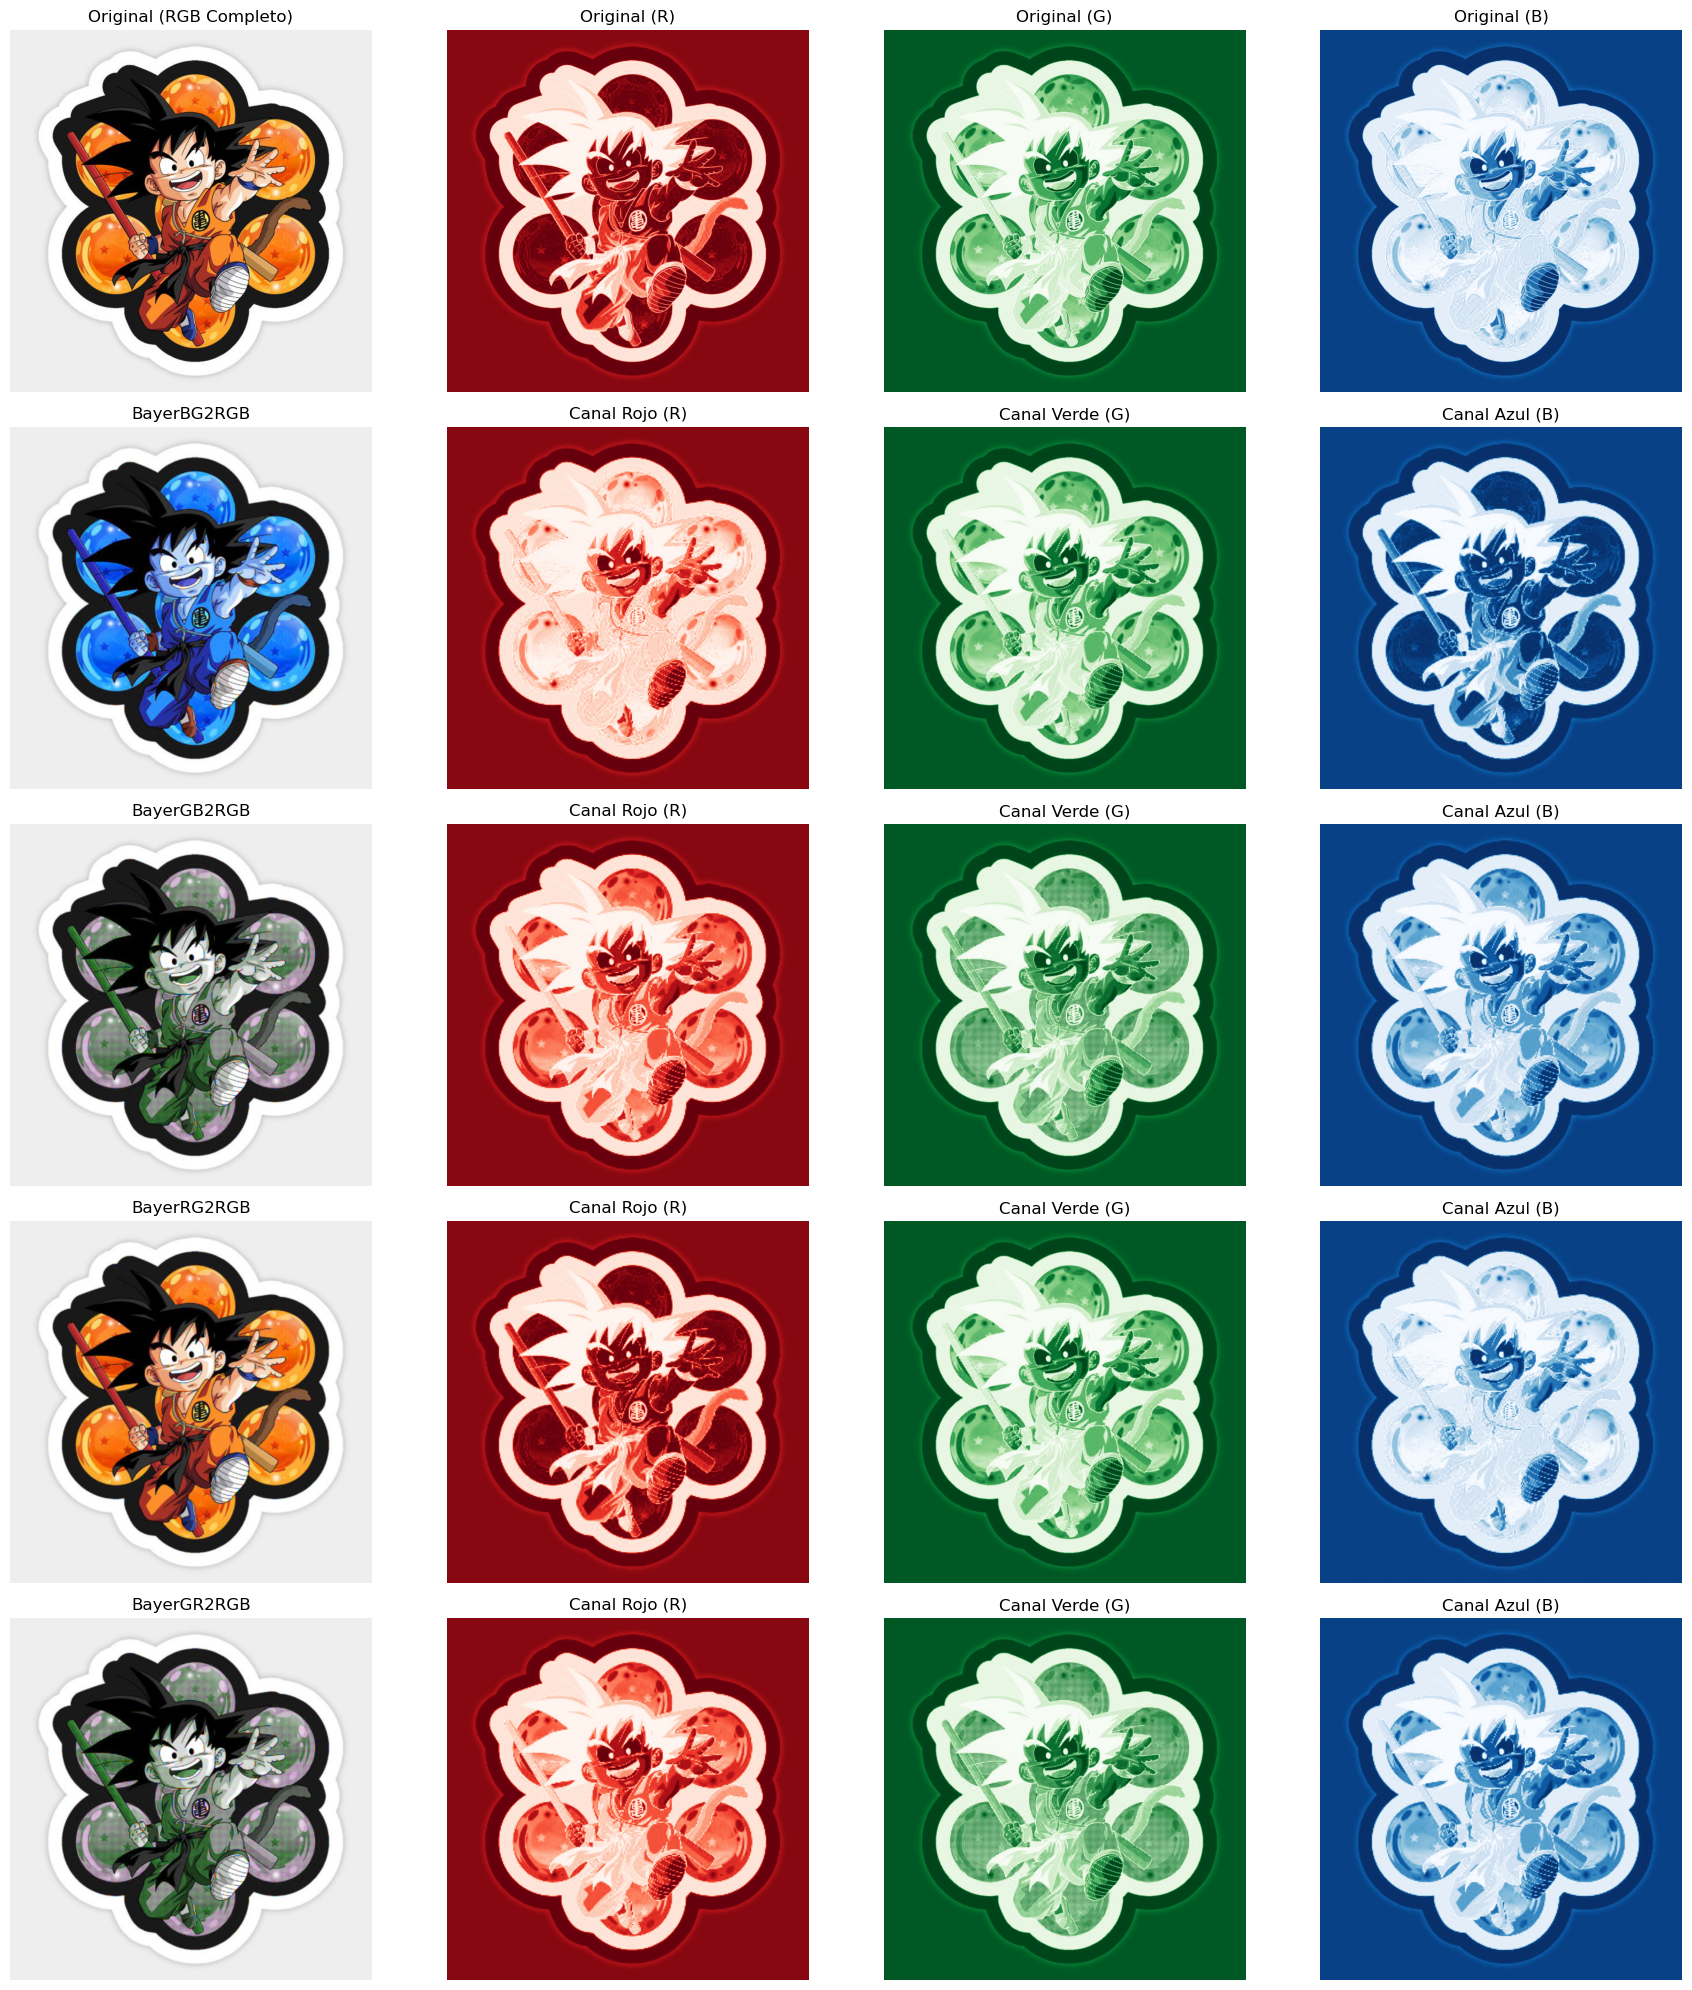

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread('goku.jpg')
img_rgb_orig = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
canal_r_orig, canal_g_orig, canal_b_orig = cv2.split(img_rgb_orig)

alto, ancho = img_bgr.shape[:2]
mosaico_bayer = np.zeros((alto, ancho), dtype=np.uint8)

mosaico_bayer[0::2, 0::2] = img_bgr[0::2, 0::2, 0] 
mosaico_bayer[0::2, 1::2] = img_bgr[0::2, 1::2, 1] 
mosaico_bayer[1::2, 0::2] = img_bgr[1::2, 0::2, 1] 
mosaico_bayer[1::2, 1::2] = img_bgr[1::2, 1::2, 2] 

versiones = {
    "BayerBG2RGB": cv2.COLOR_BayerBG2RGB,
    "BayerGB2RGB": cv2.COLOR_BayerGB2RGB,
    "BayerRG2RGB": cv2.COLOR_BayerRG2RGB,
    "BayerGR2RGB": cv2.COLOR_BayerGR2RGB
}

fig, axes = plt.subplots(5, 4, figsize=(18, 20))

axes[0, 0].imshow(img_rgb_orig)
axes[0, 0].set_title('Original (RGB Completo)')
axes[0, 0].axis('off')

axes[0, 1].imshow(canal_r_orig, cmap='Reds')
axes[0, 1].set_title('Original (R)')
axes[0, 1].axis('off')

axes[0, 2].imshow(canal_g_orig, cmap='Greens')
axes[0, 2].set_title('Original (G)')
axes[0, 2].axis('off')

axes[0, 3].imshow(canal_b_orig, cmap='Blues')
axes[0, 3].set_title('Original (B)')
axes[0, 3].axis('off')

for i, (nombre, codigo) in enumerate(versiones.items()):
    resultado_rgb = cv2.cvtColor(mosaico_bayer, codigo)
    canal_r, canal_g, canal_b = cv2.split(resultado_rgb)

    fila = i + 1

    axes[fila, 0].imshow(resultado_rgb)
    axes[fila, 0].set_title(f'{nombre}')
    axes[fila, 0].axis('off')

    axes[fila, 1].imshow(canal_r, cmap='Reds')
    axes[fila, 1].set_title('Canal Rojo (R)')
    axes[fila, 1].axis('off')

    axes[fila, 2].imshow(canal_g, cmap='Greens')
    axes[fila, 2].set_title('Canal Verde (G)')
    axes[fila, 2].axis('off')

    axes[fila, 3].imshow(canal_b, cmap='Blues')
    axes[fila, 3].set_title('Canal Azul (B)')
    axes[fila, 3].axis('off')

plt.tight_layout()
plt.show()

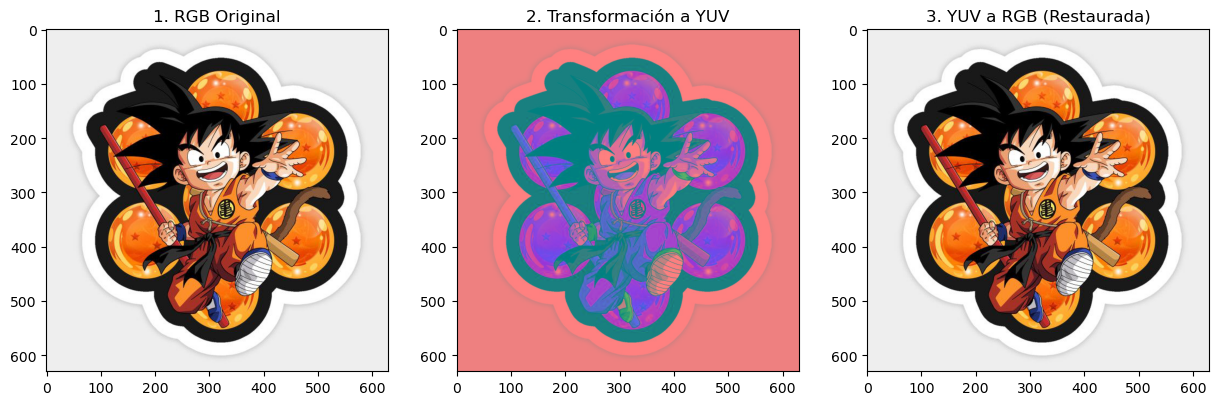

In [7]:
import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('goku.jpg')
imagen_rgb_original = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

imagen_yuv = cv2.cvtColor(imagen_rgb_original, cv2.COLOR_RGB2YUV)

imagen_rgb_restaurada = cv2.cvtColor(imagen_yuv, cv2.COLOR_YUV2RGB)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title('1. RGB Original')
plt.imshow(imagen_rgb_original)

plt.subplot(1, 3, 2)
plt.title('2. Transformación a YUV')
plt.imshow(imagen_yuv)

plt.subplot(1, 3, 3)
plt.title('3. YUV a RGB (Restaurada)')
plt.imshow(imagen_rgb_restaurada)

plt.show()